# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from skimage.measure import shannon_entropy
from scipy.ndimage import laplace

# Visualización de datos

In [2]:
DATA_DIR = Path("data")
image_files = list(DATA_DIR.glob("*.jpg"))

statistics = []
corrupted_files = []

In [3]:
for img_file in tqdm(image_files, desc="Processing images"):
    try:
        with Image.open(img_file) as img:
            img_gray = img.convert('L')
            img_array_gray = np.array(img_gray)
            img_array = np.array(img)

            width, height = img.size
            mode = img.mode

            # Look for NaN values in the image array
            has_nan = np.isnan(img_array).any()

            #  Pixel value statistics
            mean_val = np.mean(img_array)
            std_val = np.std(img_array)
            min_val = np.min(img_array)
            max_val = np.max(img_array)

            # Entropy: Measure of complexity/information content
            ent = shannon_entropy(img_array)
            
            # Sharpness: Variance of the Laplacian
            sharpness = np.var(laplace(img_array_gray))

            statistics.append({
                "filename": img_file.name,
                "width": width,
                "height": height,
                "mode": mode,
                "mean_intensity": mean_val,
                "std_intensity": std_val,
                "min_intensity": min_val,
                "max_intensity": max_val,
                "entropy": ent,
                "sharpness": sharpness,
                "has_nan": has_nan
            })
    except Exception as e:
        # If there's an corrupted file
        corrupted_files.append({'filename': img_file.name, 'error': str(e)})

df  = pd.DataFrame(statistics)

Processing images: 100%|██████████| 5446/5446 [07:22<00:00, 12.32it/s]


## Estadisticas descriptivas

In [4]:
corrupted_files

[{'filename': 'J154951.73+160402.5.jpg',
  'error': 'image file is truncated (80 bytes not processed)'},
 {'filename': 'J114739.51+100035.4.jpg',
  'error': 'image file is truncated (93 bytes not processed)'},
 {'filename': 'J134807.42+144711.9.jpg',
  'error': 'image file is truncated (8 bytes not processed)'},
 {'filename': 'J142043.76+053351.6.jpg',
  'error': 'image file is truncated (110 bytes not processed)'},
 {'filename': 'J150244.67+261252.1.jpg',
  'error': 'image file is truncated (99 bytes not processed)'},
 {'filename': 'J160131.59+362834.9.jpg',
  'error': 'image file is truncated (44 bytes not processed)'},
 {'filename': 'J143659.70+133059.7.jpg',
  'error': 'image file is truncated (109 bytes not processed)'},
 {'filename': 'J234447.50+254133.9.jpg',
  'error': 'image file is truncated (51 bytes not processed)'},
 {'filename': 'J145430.69+094226.1.jpg',
  'error': 'image file is truncated (52 bytes not processed)'},
 {'filename': 'J152516.45+532425.4.jpg',
  'error': 'i

In [5]:
df.head()

,filename,width,height,mode,mean_intensity,std_intensity,min_intensity,max_intensity,entropy,sharpness,has_nan
0,J115411.04+305652.3.jpg,800,800,RGB,40.513945,30.896488,0,255,6.336151,14140.743585,False
1,J090105.65+082536.7.jpg,800,800,RGB,37.123586,26.803691,0,255,6.368993,13101.412283,False
2,J070552.49+655739.9.jpg,800,800,RGB,36.745555,22.203929,0,255,5.971673,10077.102353,False
3,J083907.66+043402.4.jpg,800,800,RGB,53.435871,42.205530,0,255,6.662711,11292.742344,False
4,J103154.70-031818.9.jpg,800,800,RGB,34.319342,20.750330,0,255,6.150319,12495.401202,False


In [6]:
df.describe()

,width,height,mean_intensity,std_intensity,min_intensity,max_intensity,entropy,sharpness
count,5003.0,5003.0,5003.000000,5003.000000,5003.000000,5003.000000,5003.000000,5003.000000
mean,800.0,800.0,40.309662,27.918231,0.031581,254.568259,6.293839,13425.265836
std,0.0,0.0,10.278925,6.440160,0.964899,5.656597,0.321319,1233.313304
min,800.0,800.0,31.961873,0.000000,0.000000,32.000000,0.000000,0.000000
25%,800.0,800.0,36.755140,23.927473,0.000000,255.000000,6.153893,12977.203434
50%,800.0,800.0,38.564674,27.241475,0.000000,255.000000,6.309219,13696.863947
75%,800.0,800.0,41.401478,30.945381,0.000000,255.000000,6.464228,14241.604985
max,800.0,800.0,219.912874,100.133838,41.000000,255.000000,7.734024,15249.277823


## Visualización

/tmp/ipykernel_1281316/634956432.py:31: RuntimeWarning: overflow encountered in scalar add
  plt.text(i, v + 2, f'{v:.2f}', ha='center', fontweight='bold')


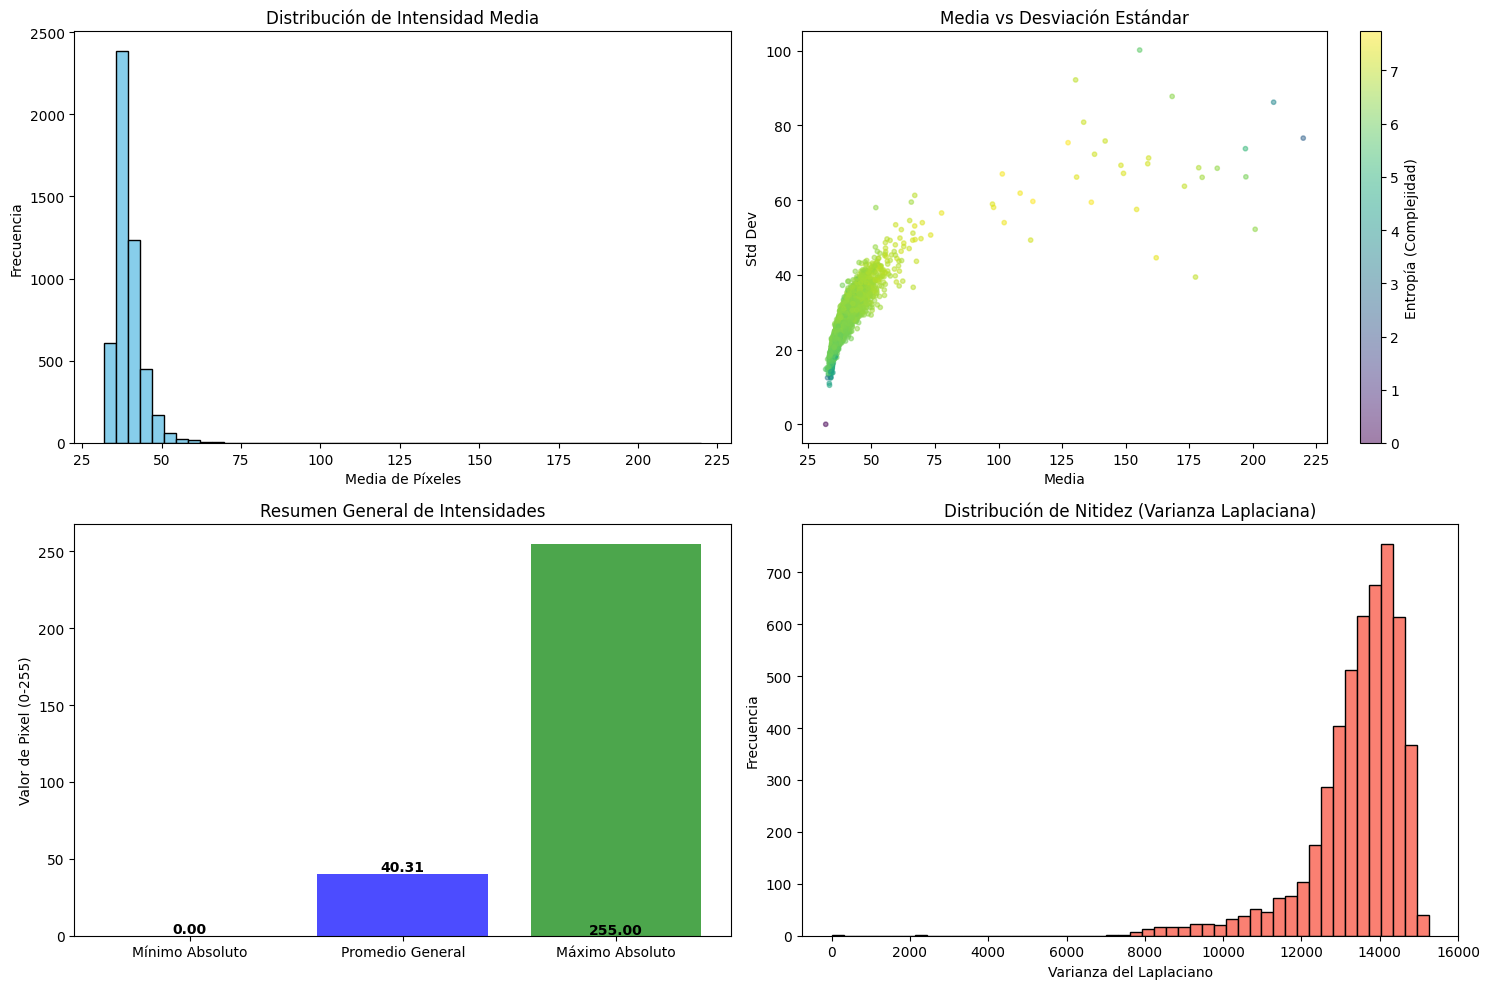

In [8]:
plt.figure(figsize=(15, 10))
# Subplot 1: Histogram of intensities
plt.subplot(2, 2, 1)
plt.hist(df['mean_intensity'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de Intensidad Media')
plt.xlabel('Media de Píxeles')
plt.ylabel('Frecuencia')

# Subplot 2: Mean vs Std (Contrast)
plt.subplot(2, 2, 2)
plt.scatter(df['mean_intensity'], df['std_intensity'], alpha=0.5, s=10, c=df['entropy'], cmap='viridis')
plt.colorbar(label='Entropía (Complejidad)')
plt.title('Media vs Desviación Estándar')
plt.xlabel('Media')
plt.ylabel('Std Dev')

# Subplot 3: Bar chart of global Min, Mean, Max
plt.subplot(2, 2, 3)
global_min = df['min_intensity'].min()
global_mean = df['mean_intensity'].mean()
global_max = df['max_intensity'].max()

labels = ['Mínimo Absoluto', 'Promedio General', 'Máximo Absoluto']
values = [global_min, global_mean, global_max]
colors = ['red', 'blue', 'green']

plt.bar(labels, values, color=colors, alpha=0.7)
plt.title('Resumen General de Intensidades')
plt.ylabel('Valor de Pixel (0-255)')
for i, v in enumerate(values):
    plt.text(i, v + 2, f'{v:.2f}', ha='center', fontweight='bold')

# Subplot 4: Sharpness Distribution
plt.subplot(2, 2, 4)
plt.hist(df['sharpness'], bins=50, color='salmon', edgecolor='black')
plt.title('Distribución de Nitidez (Varianza Laplaciana)')
plt.xlabel('Varianza del Laplaciano')
plt.ylabel('Frecuencia')

plt.tight_layout()

plt.tight_layout()